In [16]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals


Learning from part 1 and will revert to default for parameters that appear to have no correlation or little importance.

defaults:
- sar_maximum -->  0.2
- sar_acceleration --> 0.02
- ce_high_length --> 22
- atr_length --> 14


Explore further but can shrink search space:
- adx_length --> < 20
- adx_threshold -->  <25
- ce_low_length --> <20
- atr_multiplier --> <3

In [17]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 1000
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-06-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 25,
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

#benchmark, buy and hold
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-06-28 12:00:00+00:00  107518.296875  6508.646973
2025-06-28 16:00:00+00:00  107277.796875  6494.088379
2025-06-28 20:00:00+00:00  107325.101562  6496.952148
2025-06-29 00:00:00+00:00  107234.101562  6491.443359
2025-06-29 04:00:00+00:00  107371.500000  6499.760742
2025-06-29 08:00:00+00:00  108452.398438  6565.193359
2025-06-29 12:00:00+00:00  107789.203125  6525.046387
2025-06-29 16:00:00+00:00  107450.500000  6504.542480
2025-06-29 20:00:00+00:00  108387.203125  6561.246094
2025-06-30 00:00:00+00:00  108509.703125  6568.662109


#Optuna setup

In [18]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", -10, 25)  #
    params['adx_length'] = trial.suggest_int("adx_length", 0, 20)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 0.1, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 0.3, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", .1, 3, step=0.1)
    # params['atr_length'] = trial.suggest_int("atr_length", 1, 30)
    params['ce_low_length'] = trial.suggest_int("ce_low_length", 0, 20)
    # params['ce_high_length'] = trial.suggest_int("ce_high_length", 1, 30)

    s = Signals(**params)

    signals = s.calc_signals(df.copy())
    bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee, start_equity=start_equity)
    stats, profit_df = bt.run()

    sortino = stats['sortino']
    return sortino


study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)

[I 2025-11-07 16:51:34,052] A new study created in memory with name: no-name-e39c50ac-3e16-47e3-9174-0e9b6d055543
[I 2025-11-07 16:51:34,217] Trial 0 finished with value: 6.291803711226223 and parameters: {'adx_threshold': 3, 'adx_length': 19, 'atr_multiplier': 2.2, 'ce_low_length': 12}. Best is trial 0 with value: 6.291803711226223.
[I 2025-11-07 16:51:34,398] Trial 1 finished with value: 3.919934584946363 and parameters: {'adx_threshold': -5, 'adx_length': 3, 'atr_multiplier': 0.2, 'ce_low_length': 18}. Best is trial 0 with value: 6.291803711226223.
[I 2025-11-07 16:51:34,558] Trial 2 finished with value: 3.580470707022201 and parameters: {'adx_threshold': 11, 'adx_length': 14, 'atr_multiplier': 0.1, 'ce_low_length': 20}. Best is trial 0 with value: 6.291803711226223.
[I 2025-11-07 16:51:34,720] Trial 3 finished with value: 7.902418240658506 and parameters: {'adx_threshold': 19, 'adx_length': 4, 'atr_multiplier': 0.6, 'ce_low_length': 3}. Best is trial 3 with value: 7.902418240658506

Study Results

In [19]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |    value |   adx_length |   adx_threshold |   atr_multiplier |   ce_low_length |
|----------|----------|--------------|-----------------|------------------|-----------------|
|      917 | 14.6305  |            9 |             -10 |              0.8 |               1 |
|      582 | 14.6237  |            1 |              12 |              0.8 |               1 |
|      877 | 13.5248  |            1 |              20 |              1.1 |               1 |
|      248 | 13.271   |           12 |              -1 |              1.1 |               1 |
|      871 | 13.271   |           12 |              10 |              1.1 |               1 |
|      150 | 13.2118  |            5 |              -4 |              0.6 |               1 |
|      423 | 13.0799  |            3 |               4 |              1.2 |               1 |
|      826 | 12.9907  |            7 |              -3 |              1.2 |               1 |
|      720 | 12.5715  |           17 |               1 |    

In [20]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sortino: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sortino: 14.63 
|----------------|-------|
| adx_threshold  | -10   |
| adx_length     |   9   |
| atr_multiplier |   0.8 |
| ce_low_length  |   1   |


Visualization

In [21]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length is good when < 10, I think best to cheap default of 14
- ADX_threshold looks like once it's under 20, there's not much correlation.
- ATR_length has little correlation so will keep at default of 14
- ce_high_length, keep the default value of 22
- ce_low_length the highest sortino values are achieved when ce_low_length is low, under 10
- sar_maximum is okay, keep the default of 0.2
- sar_acceleration is okay, keep the default of 0.02


Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.


NOTE:  Removed atr_length and ce_high_length from the slice plot, since they have very little correlation to sortino ratio.


In [22]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

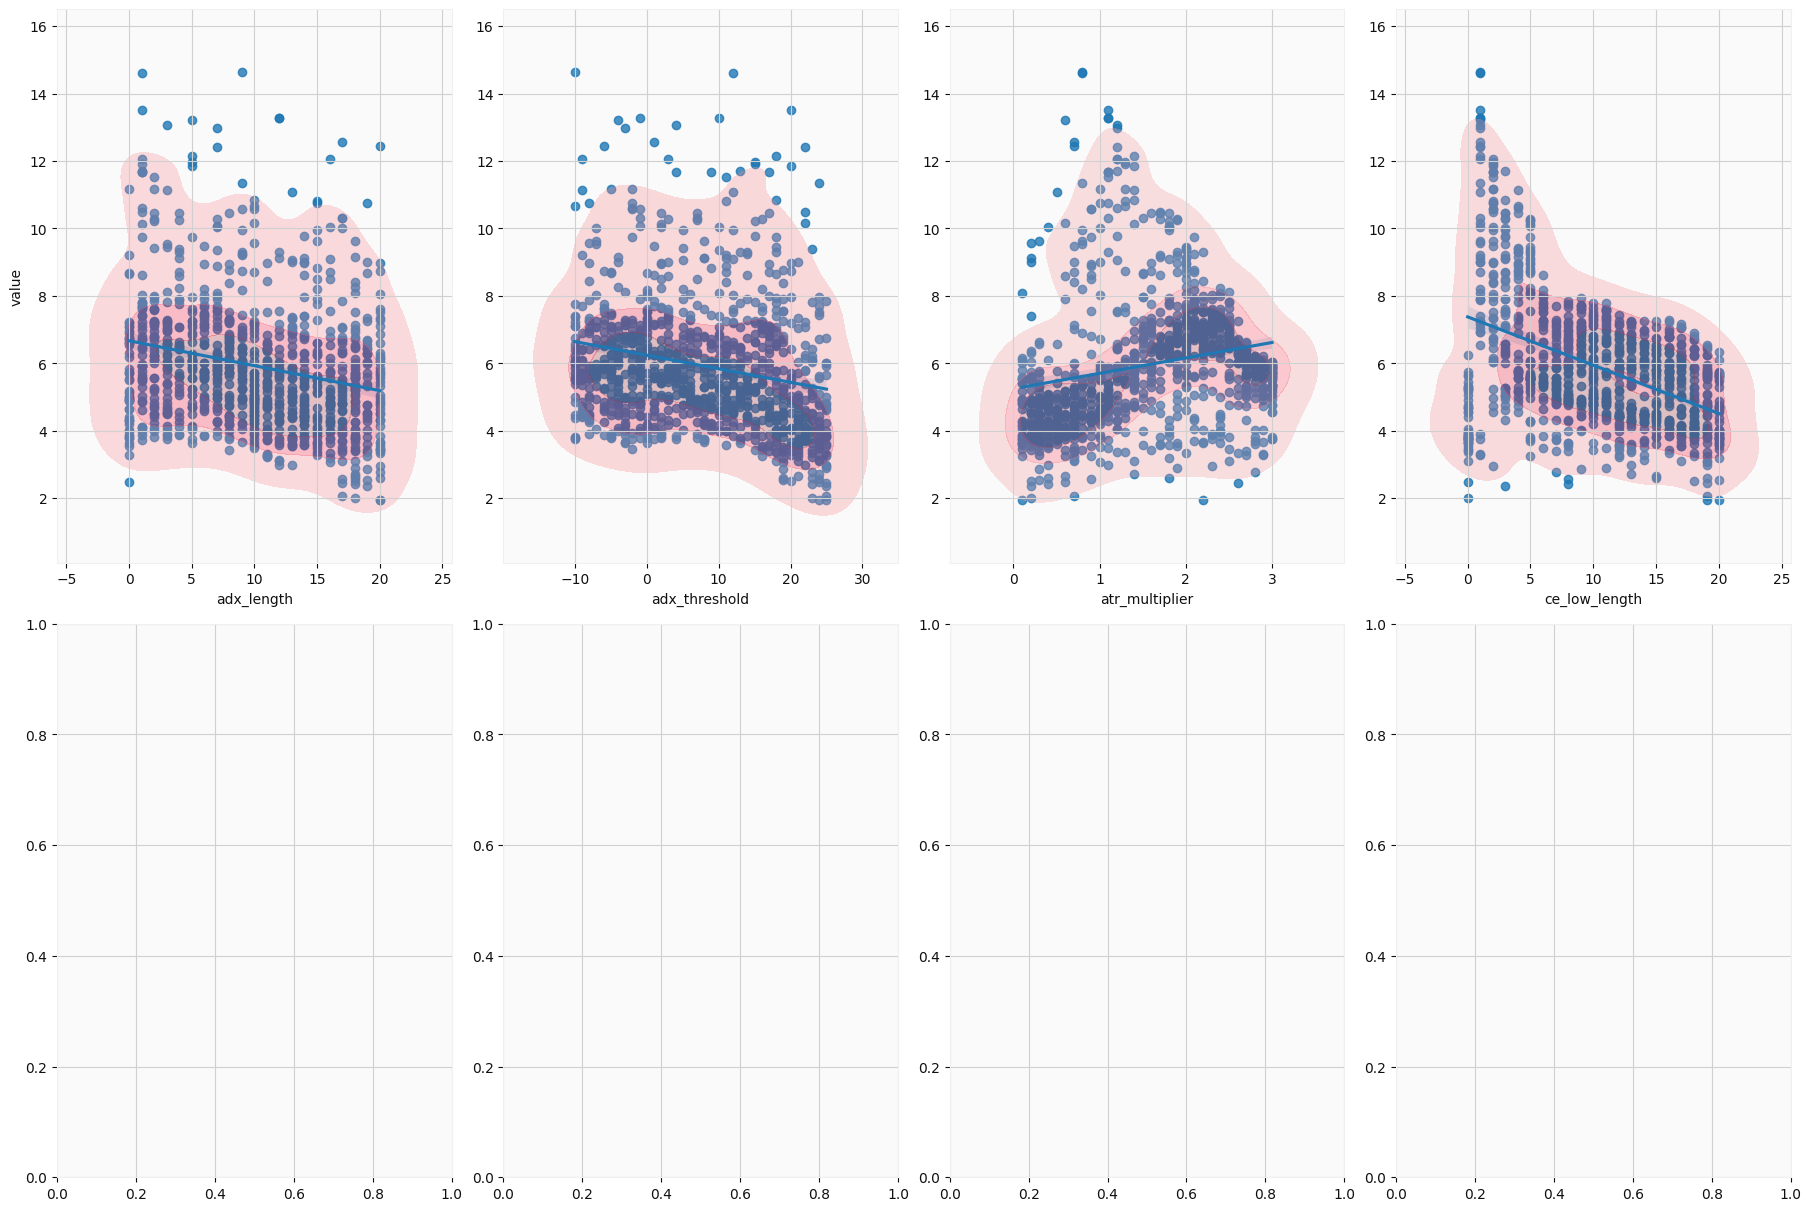

In [23]:
x_all = list(trials.columns[2:])
y_col = trials.columns[1]

fig, axes = plt.subplots(2, 4, figsize=(18, 12), constrained_layout=True)
for i, col in enumerate(x_all[:8]):  # first 8 columns
    ax = axes[i // 4, i % 4]
    sns.regplot(data=trials, x=col, y=y_col, ax=ax)
    sns.kdeplot(data=trials, x=col, y=y_col, levels=4, fill=True, color='crimson', alpha=0.3, ax=ax)
    ax.set_xlabel(col)
    if i % 4 != 0:
        ax.set_ylabel("")
plt.show()

Best Trial Backtest

In [24]:
s = Signals(**best_params)
signals = s.calc_signals(df.copy())
bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee)
stats, profit_df = bt.run()

print(f"\n Stats")
print(tabulate(stats.items(), tablefmt="github"))
print(f"\n Profit DataFrame")
print(profit_df.tail().to_string())


 Stats
|------------------|--------------|
| trading_days     |    911       |
| total_profit     | 108753       |
| total_profit_pct |  10875.3     |
| sharpe           |      6.71735 |
| sortino          |     14.6305  |
| wins             |    221       |
| losses           |     25       |
| win_rate         |     89.8374  |

 Profit DataFrame
                             Entry_Price     Exit_Price          close   Returns  Window_Profit         Equity
2025-06-29 08:00:00+00:00  108452.398438       0.000000  108452.398438  0.006817       0.006817  109388.090497
2025-06-29 12:00:00+00:00       0.000000  107895.541622  107789.203125 -0.003250            NaN  109032.579203
2025-06-29 16:00:00+00:00       0.000000       0.000000  107450.500000  0.000000            NaN  109032.579203
2025-06-29 20:00:00+00:00  108387.203125       0.000000  108387.203125  0.005468            NaN  109628.718271
2025-06-30 00:00:00+00:00       0.000000       0.000000  108509.703125  0.001130       0.00660

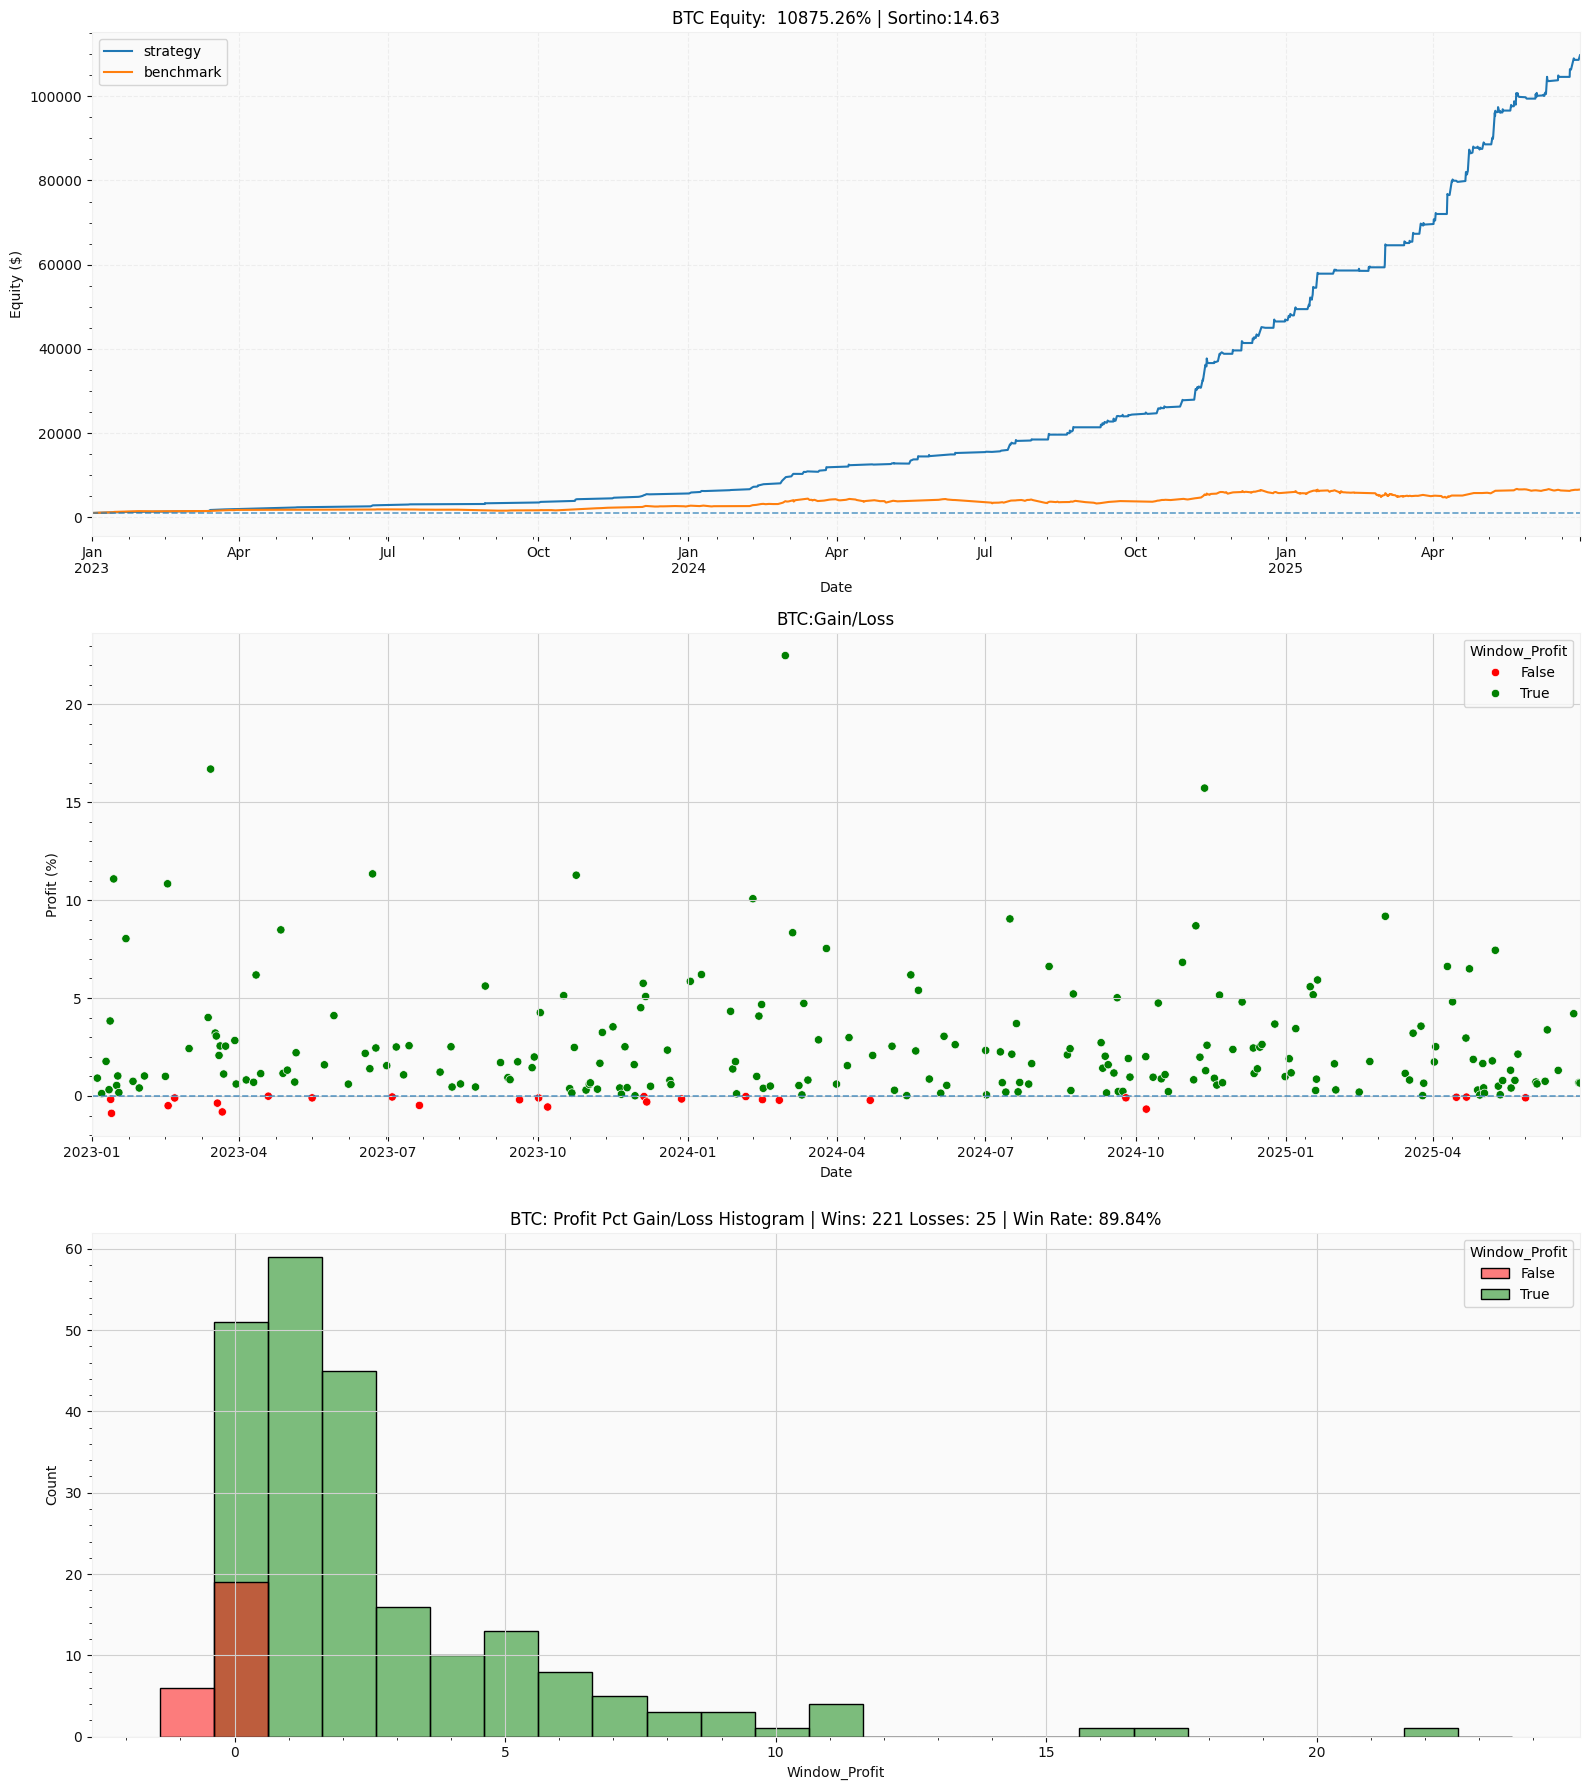

In [25]:
# plots
win_profit = profit_df['Window_Profit'] * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

#Equity Plot
profit_df['Equity'].plot(ax=axes[0],
                         title=f'{symbols[0]} Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{best_value:.2f}',
                         label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].set_xlabel('Date')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle="--")
# axes[0].set_yscale('log')
axes[0].set_xlim(start, end)
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].minorticks_on()

#Gain/Loss Plot
sns.scatterplot(x=profit_df.index, y=win_profit, ax=axes[1], hue=win_profit > 0, palette={True: 'green', False: 'red'})
axes[1].set_title(f'{symbols[0]}:Gain/Loss')
axes[1].set_ylabel('Profit (%)')
axes[1].set_xlabel('Date')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_xlim(start, end)
axes[1].minorticks_on()
plt.tight_layout()

# Histogram Gain/Loss
sns.histplot(profit_df,
             x=win_profit,
             hue=win_profit > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[2]
             )
axes[2].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {stats['wins']} Losses: {stats['losses']} | Win Rate: {stats['win_rate']:.2f}%")
axes[2].minorticks_on()
plt.tight_layout()
plt.show()

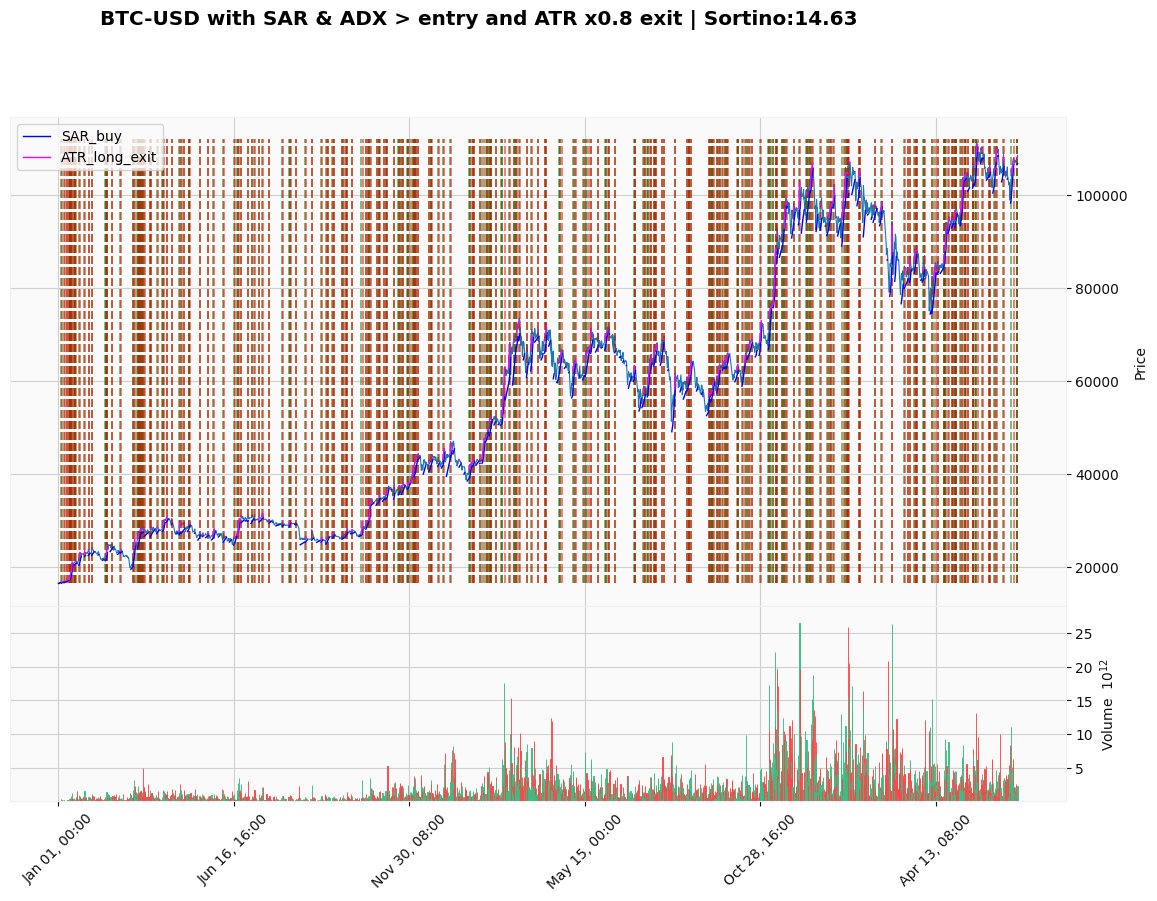

In [26]:
# Combine and color differently
##  Boolean where in position

y1_arr = signals['close'].values
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
in_position = signals['in_position']

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates = [ts for ts, _ in pairs]
vline_colors = [c for _, c in pairs]

zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 12),
    figscale=1.7,
    tight_layout=False,
    title=f"{symbols[0]}-USD with SAR & ADX > entry and ATR x{best_params['atr_multiplier']:.1f} exit | Sortino:{best_value:.2f}",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)